In [2]:
%load_ext autoreload
%autoreload 2

In [32]:
import os
from pathlib import Path

import dask
import geopandas as gpd
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from nu_segregation.constants import LINKING_COLS
from nu_segregation.defs.assets.prod import get_seg_full

In [56]:
out_path = Path(os.environ["OUT_PATH"])
ZONE = "19.1.01"

In [66]:
test = []
for year in [2018, 2020, 2022]:
    test.append(
        gpd.read_parquet(out_path / "income" / str(year) / f"{ZONE}.geoparquet")
        .set_index("cvegeo")["income_pc"]
        .rename(year)
    )

df_test = pd.concat(test, axis=1)

<Axes: ylabel='Frequency'>

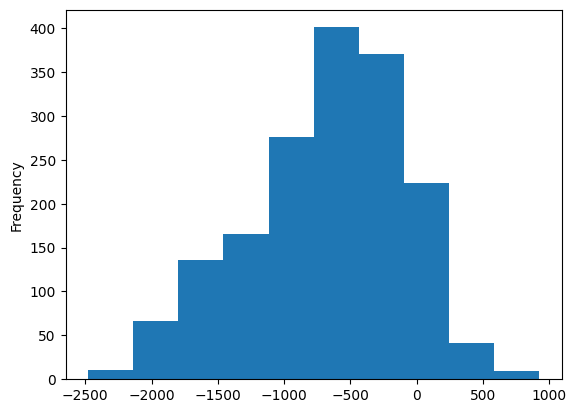

In [73]:
(df_test[2020] - df_test[2018]).plot.hist()

In [53]:
df_survey = pd.DataFrame(
    pd.read_parquet(out_path / "survey" / str(YEAR) / f"{ZONE}.parquet")
)
df_census = pd.DataFrame(
    pd.read_parquet(out_path / "census" / str(YEAR) / f"{ZONE}.parquet")
)
df_census_geometry = (
    gpd.read_file(out_path / "census_geometries" / str(YEAR) / f"{ZONE}.gpkg")
    .set_index("cvegeo")
    .pipe(lambda df: df.to_crs(df.estimate_utm_crs()))
)

FileNotFoundError: [Errno 2] No such file or directory: 'C:\\Users\\lain\\OneDrive - Instituto Tecnologico y de Estudios Superiores de Monterrey\\segregation_data\\generated\\census\\2018\\01.1.01.parquet'

In [28]:
df_income = gpd.read_parquet(out_path / "income" / f"{ZONE}.geoparquet")

<Axes: >

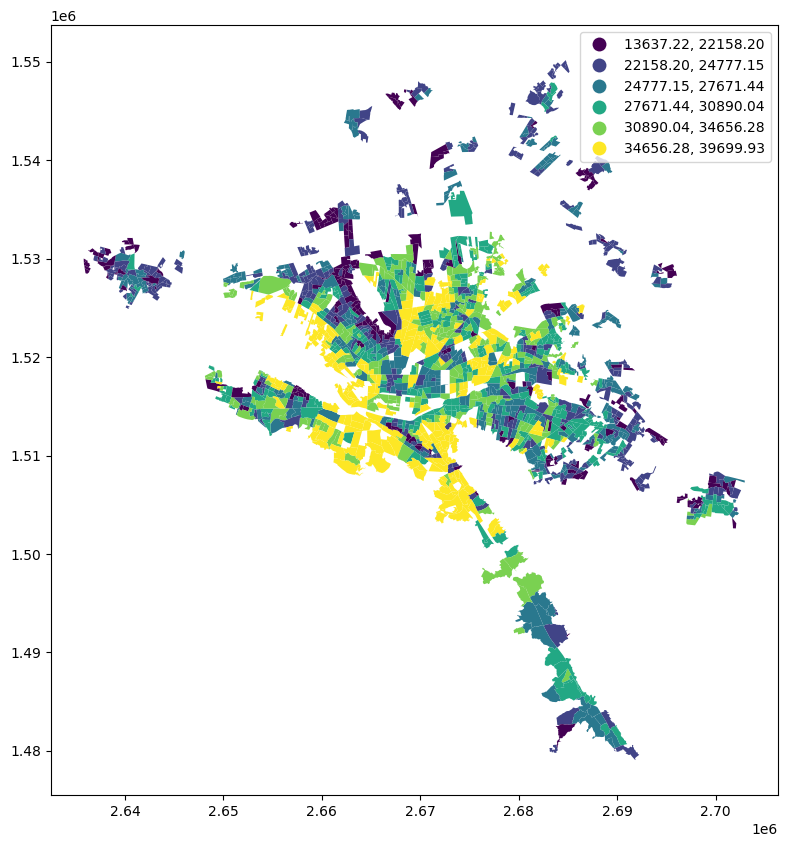

In [44]:
fig, ax = plt.subplots(figsize=(10, 10))
df_income.plot(column="income_pc", ax=ax, legend=True, scheme="natural_breaks", k=6)

In [20]:
df_census_geometry.to_parquet("./test.geoparquet")

In [57]:
testd, test, C, C_list = get_seg_full(
    df_census, df_census_geometry, df_survey, out_path="./results/"
)

In [10]:
pd.crosstab(
    [df_survey[c] for c in LINKING_COLS],
    df_survey["Ingreso"],
    dropna=False,
).stack()

Sexo  Edad    Nivel      SeguroIMSS  SeguroPriv  ConexionInt  Ingreso
m     p15_64  ninguno    no_imss     no_privado  internet     1.0        2
                                                              2.0        3
                                                              3.0        1
                                                              4.0        0
                                                              5.0        0
                                                                        ..
f     p65mas  posbasica  imss        privado     no_internet  1.0        0
                                                              2.0        0
                                                              3.0        0
                                                              4.0        0
                                                              5.0        0
Length: 640, dtype: int64

In [52]:
pd.DataFrame(testd["cent_idx"]["q_1"])

,k_5,k_100
0,0.012607,0.025815
1,-0.029734,-0.027652
2,-0.063127,0.000342
3,-0.062608,0.001745
4,-0.043337,0.003264
...,...,...
322,-0.023088,0.014156
323,0.035894,-0.024536
324,0.007649,0.015537
325,0.011246,0.020574


In [ ]:
n_samples = 32
n_ind = len(df_survey)

rng = np.random.default_rng(seed=42)
bs_idxs = rng.integers(0, n_ind, size=(n_samples, n_ind))

get_seg_full_delayed = dask.delayed(get_seg_full)

In [ ]:
temp = df_survey.iloc[bs_idxs[0]].reset_index(drop=True)
res = get_seg_full_delayed(
    df_census,
    temp,
)